# Individual Comparison on HPN

This notebook reproduces the HPN individual-parcellation comparison plots from the released result files. It compares individual parcellations trained from rest and fusion priors using task inhomogeneity, DCBC, and resting-state homogeneity.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

sb.set_theme(style="ticks", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.linewidth"] = 1.2

In [2]:
def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "train_group.py").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Could not locate the IndividualParcellation repo root.")


REPO_ROOT = find_repo_root()
RESULT_DIR = REPO_ROOT / "results" / "5.hpn"
OUTPUT_DIR = RESULT_DIR / "figures"
SAVE_FIGURES = False

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK_FILE = RESULT_DIR / "eval_rest_vs_fusion_RANDYrest-1-allrun_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv"
REST_FILE = RESULT_DIR / "eval_rest_vs_fusion_RANDYrest-1-allrun_K-15_indiv-mRBM_test_on_RANDYrest-Tseries_sm0_11subjects.tsv"
DICE_FILE = RESULT_DIR / "dice_within_vs_between_RANDY_rest1run_K-15.tsv"
FIG6C_PDF = RESULT_DIR / "zoom-in_effect_LANG.pdf"
Z_VALUE_LANG_FILE = RESULT_DIR / "Z_value_LANG.tsv"
FIG6E_PDF = RESULT_DIR / "zoom-in_effect_SMB.pdf"
Z_VALUE_SMB_FILE = RESULT_DIR / "Z_value_SMB.tsv"

RESULT_DIR

PosixPath('/home/dzhi/Workspace/IndividualParcellation/results/5.hpn')

In [3]:
task_eval_raw = pd.read_csv(TASK_FILE, sep="	")
rest_eval_raw = pd.read_csv(REST_FILE, sep="	")

HUE_ORDER = ["rest", "fusion"]
TASK_TRAIN_ORDER = ["1", "5", "10", "15", "all"]
REST_TRAIN_ORDER = ["1", "3", "5", "7", "10"]


def prepare_eval_table(df, train_order):
    out = df.copy()
    out["type"] = out["group_map_name"].astype(str)
    out = out[out["type"].isin(HUE_ORDER)].copy()
    out["type"] = pd.Categorical(out["type"], categories=HUE_ORDER, ordered=True)
    out["train_runs_label"] = out["train_runs"].astype(str)
    out["train_runs_label"] = pd.Categorical(
        out["train_runs_label"], categories=train_order, ordered=True
    )
    out = out.dropna(subset=["train_runs_label"]).sort_values(["train_runs_label", "type", "subj_num"])
    return out


task_eval = prepare_eval_table(task_eval_raw, TASK_TRAIN_ORDER)
rest_eval = prepare_eval_table(rest_eval_raw, REST_TRAIN_ORDER)

# The rest table contains repeated rows per subject/test run. Collapse to one
# subject-level value per prior and training-run condition for plotting/testing.
rest_plot = (
    rest_eval
    .groupby(["subj_num", "type", "train_runs_label"], observed=True, as_index=False)
    .mean(numeric_only=True)
)

summary = pd.DataFrame([
    {
        "source": "task-contrast evaluation table",
        "analysis": "HPN task contrasts",
        "rows": len(task_eval),
        "n_subjects": task_eval["subj_num"].nunique(),
        "train_runs": ", ".join(TASK_TRAIN_ORDER),
        "priors": ", ".join(HUE_ORDER),
    },
    {
        "source": "resting-state evaluation table",
        "analysis": "HPN rest Tseries",
        "rows": len(rest_eval),
        "n_subjects": rest_eval["subj_num"].nunique(),
        "train_runs": ", ".join(REST_TRAIN_ORDER),
        "priors": ", ".join(HUE_ORDER),
    },
])
summary

,source,analysis,rows,n_subjects,train_runs,priors
0,task-contrast evaluation table,HPN task contrasts,110,11,"1, 5, 10, 15, all","rest, fusion"
1,resting-state evaluation table,HPN rest Tseries,3750,15,"1, 3, 5, 7, 10","rest, fusion"


In [4]:
# Plot style adapted from notebooks/res4.ipynb.
PALETTE = {
    "rest": "#EE6677",
    "fusion": "#009E73",
}
BAR_WIDTH = 0.52
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15


def stroke_bars(ax):
    for bar in ax.patches:
        bar.set_edgecolor(EDGE_COLOR)
        bar.set_linewidth(EDGE_WIDTH)


def move_legend_outside(ax, anchor=(-0.02, 1.22), ncol=None):
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    ax.legend(
        handles[:len(HUE_ORDER)],
        labels[:len(HUE_ORDER)],
        title="Prior",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=anchor,
        borderaxespad=0,
        ncol=ncol or len(HUE_ORDER),
    )


def style_axis(ax, title, ylabel=None, ylim=None, legend=True,
               legend_anchor=(-0.02, 1.22), legend_ncol=None):
    stroke_bars(ax)
    ax.set_title(title)
    ax.set_xlabel("Training runs")
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=45)
    if legend:
        move_legend_outside(ax, anchor=legend_anchor, ncol=legend_ncol)
    elif ax.get_legend() is not None:
        ax.get_legend().remove()
    sb.despine(ax=ax)


def bar_ylim(data, metric, group_cols=("train_runs_label", "type"), pad_fraction=0.35):
    summary = (
        data
        .groupby(list(group_cols), observed=True)[metric]
        .agg(["mean", "sem"])
        .reset_index()
    )
    lower = (summary["mean"] - summary["sem"].fillna(0)).min()
    upper = (summary["mean"] + summary["sem"].fillna(0)).max()
    span = upper - lower
    pad = max(span * pad_fraction, 0.005)
    return lower - pad, upper + pad


def barplot_metric(data, x, y, ax, order, ylim=None, title=None, ylabel=None,
                   legend=True, legend_anchor=(-0.02, 1.22), legend_ncol=None):
    sb.barplot(
        data=data,
        x=x,
        y=y,
        hue="type",
        hue_order=HUE_ORDER,
        order=order,
        errorbar="se",
        capsize=CAPSIZE,
        width=BAR_WIDTH,
        palette=PALETTE,
        dodge=True,
        ax=ax,
    )
    style_axis(ax, title or y, ylabel=ylabel, ylim=ylim, legend=legend,
               legend_anchor=legend_anchor, legend_ncol=legend_ncol)
    return ax


def overlay_subject_points(data, x, y, ax, order, seed=42):
    rng = np.random.default_rng(seed)
    type_offsets = {
        prior: offset
        for prior, offset in zip(HUE_ORDER, np.linspace(-BAR_WIDTH / 4, BAR_WIDTH / 4, len(HUE_ORDER)))
    }
    x_positions = {label: i for i, label in enumerate(order)}

    for prior in HUE_ORDER:
        sub = data[data["type"].astype(str) == prior].copy()
        if sub.empty:
            continue
        base_x = sub["train_runs_label"].astype(str).map(x_positions).to_numpy(dtype=float)
        jitter = rng.uniform(-0.035, 0.035, size=len(sub))
        ax.scatter(
            base_x + type_offsets[prior] + jitter,
            sub[y],
            s=34,
            c=PALETTE[prior],
            edgecolor="gray",
            linewidth=0.45,
            alpha=0.85,
            zorder=5,
        )

In [5]:
def subject_metric(df, metric, prior, train_runs_label):
    sub = df[(df["type"].astype(str) == prior) &
             (df["train_runs_label"].astype(str) == str(train_runs_label))]
    return sub.groupby("subj_num")[metric].mean()


def paired_ttest(df, metric, train_runs_label, type_a="rest", type_b="fusion"):
    a = subject_metric(df, metric, type_a, train_runs_label)
    b = subject_metric(df, metric, type_b, train_runs_label)
    common = a.index.intersection(b.index)
    a = a.loc[common].sort_index()
    b = b.loc[common].sort_index()
    result = stats.ttest_rel(a, b)
    return {
        "comparison": f"{type_a} vs {type_b}",
        "metric": metric,
        "train_runs": str(train_runs_label),
        "n": len(common),
        f"mean_{type_a}": float(a.mean()),
        f"mean_{type_b}": float(b.mean()),
        f"mean_diff_{type_b}-{type_a}": float((b - a).mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    }


def paired_ttest_table(df, metrics, train_order):
    rows = []
    for metric in metrics:
        for train_runs_label in train_order:
            rows.append(paired_ttest(df, metric, train_runs_label))
    out = pd.DataFrame(rows)
    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(6)
    return out

## HPN Task Evaluation

Task-contrast evaluation reports task inhomogeneity and DCBC for individual parcellations trained from rest or fusion priors. Lower task inhomogeneity and higher DCBC indicate better evaluation performance.

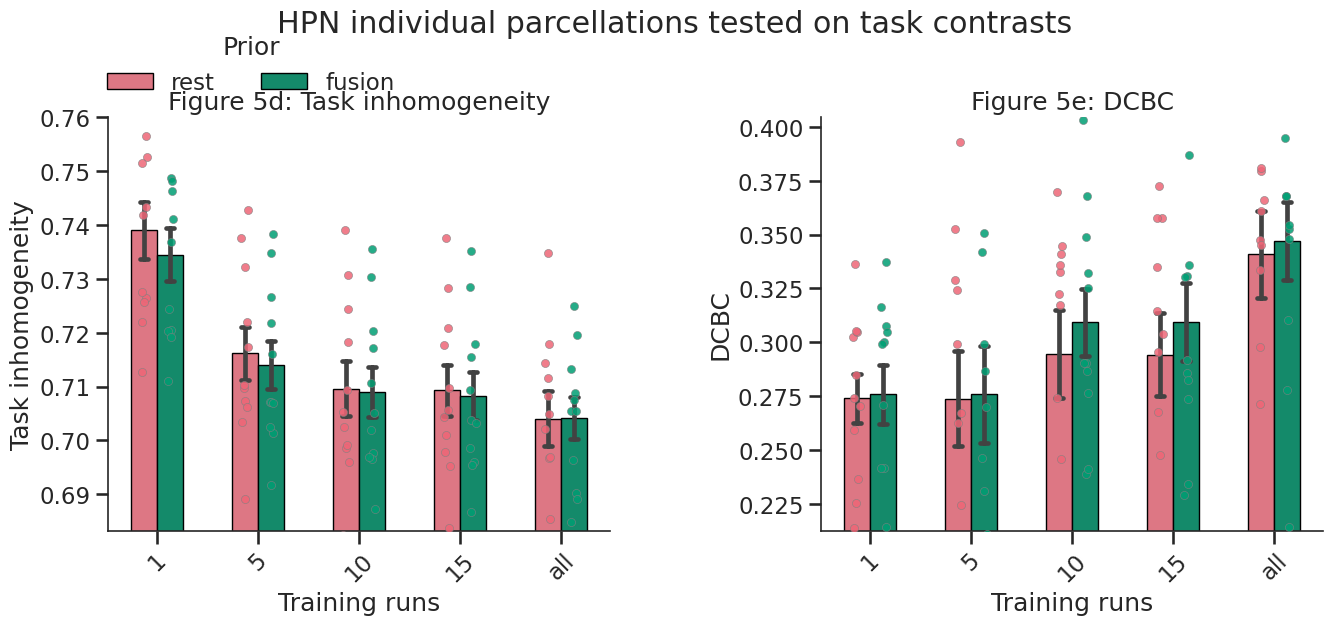

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharex=True)

task_inhomo_subject = (
    task_eval
    .groupby(["subj_num", "type", "train_runs_label"], observed=True, as_index=False)
    .mean(numeric_only=True)
)

task_dcbc_subject = task_inhomo_subject.copy()

barplot_metric(
    task_eval,
    x="train_runs_label",
    y="inhomo_indiv",
    ax=axes[0],
    order=TASK_TRAIN_ORDER,
    ylim=bar_ylim(task_eval, "inhomo_indiv"),
    title="Figure 5d: Task inhomogeneity",
    ylabel="Task inhomogeneity",
    legend=True,
)
overlay_subject_points(task_inhomo_subject, "train_runs_label", "inhomo_indiv",
                       axes[0], TASK_TRAIN_ORDER, seed=42)

barplot_metric(
    task_eval,
    x="train_runs_label",
    y="dcbc_indiv",
    ax=axes[1],
    order=TASK_TRAIN_ORDER,
    ylim=bar_ylim(task_eval, "dcbc_indiv"),
    title="Figure 5e: DCBC",
    ylabel="DCBC",
    legend=False,
)
overlay_subject_points(task_dcbc_subject, "train_runs_label", "dcbc_indiv",
                       axes[1], TASK_TRAIN_ORDER, seed=43)

fig.suptitle("HPN individual parcellations tested on task contrasts", y=0.98)
fig.subplots_adjust(wspace=0.42, right=0.98, top=0.80, left=0.08)

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_5d_5e_HPN_task_inhomogeneity_DCBC.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
task_ttests = paired_ttest_table(task_eval, ["inhomo_indiv", "dcbc_indiv"], TASK_TRAIN_ORDER)
task_ttests

,comparison,metric,train_runs,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,rest vs fusion,inhomo_indiv,1,11,0.738993,0.734489,-0.004504,5.466469,0.000274
1,rest vs fusion,inhomo_indiv,5,11,0.716166,0.714047,-0.002120,3.074329,0.011754
2,rest vs fusion,inhomo_indiv,10,11,0.709600,0.709047,-0.000553,0.581924,0.573502
3,rest vs fusion,inhomo_indiv,15,11,0.709283,0.708190,-0.001093,1.630410,0.134068
4,rest vs fusion,inhomo_indiv,all,11,0.704061,0.704174,0.000112,-0.060367,0.953053
5,rest vs fusion,dcbc_indiv,1,11,0.274010,0.275857,0.001848,-0.185979,0.856180
6,rest vs fusion,dcbc_indiv,5,11,0.273970,0.275976,0.002007,-0.205366,0.841407
7,rest vs fusion,dcbc_indiv,10,11,0.294655,0.309293,0.014637,-1.150795,0.276591
8,rest vs fusion,dcbc_indiv,15,11,0.294338,0.309514,0.015177,-1.629486,0.134265
9,rest vs fusion,dcbc_indiv,all,11,0.340805,0.346840,0.006035,-0.407566,0.692180


## HPN Resting-State Homogeneity

Resting-state evaluation reports homogeneity only. The released table contains repeated test-run rows, so values are averaged within subject, prior, and training-run condition before plotting and paired testing.

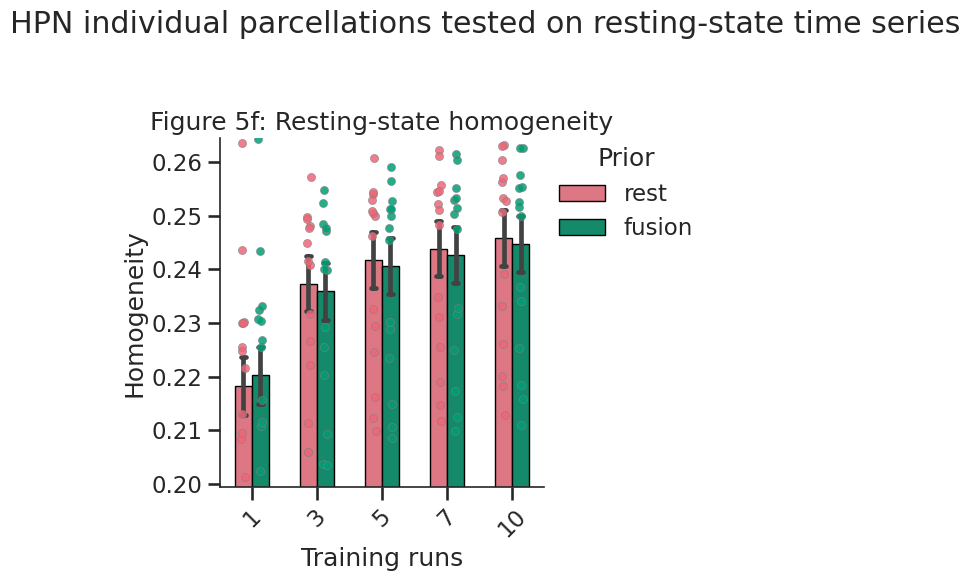

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7.8, 6))

barplot_metric(
    rest_plot,
    x="train_runs_label",
    y="homo_indiv",
    ax=ax,
    order=REST_TRAIN_ORDER,
    ylim=bar_ylim(rest_plot, "homo_indiv"),
    title="Figure 5f: Resting-state homogeneity",
    ylabel="Homogeneity",
    legend=True,
    legend_anchor=(1.02, 1.0),
    legend_ncol=1,
)
overlay_subject_points(rest_plot, "train_runs_label", "homo_indiv",
                       ax, REST_TRAIN_ORDER, seed=44)

fig.suptitle("HPN individual parcellations tested on resting-state time series", y=0.98)
fig.tight_layout(rect=[0, 0, 0.82, 0.95])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_5f_HPN_rest_homogeneity.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
rest_ttests = paired_ttest_table(rest_plot, ["homo_indiv"], REST_TRAIN_ORDER)
rest_ttests

,comparison,metric,train_runs,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,rest vs fusion,homo_indiv,1,15,0.218161,0.220255,0.002095,-3.555001,0.003169
1,rest vs fusion,homo_indiv,3,15,0.237307,0.235897,-0.001410,3.717377,0.002297
2,rest vs fusion,homo_indiv,5,15,0.241708,0.240705,-0.001003,3.362203,0.004650
3,rest vs fusion,homo_indiv,7,15,0.243846,0.242747,-0.001099,5.097256,0.000163
4,rest vs fusion,homo_indiv,10,15,0.245892,0.244673,-0.001219,4.744893,0.000313


## HPN Within- Versus Between-Individual Parcellation Similarity

This panel compares Dice similarity within the same individual across run pairs and between different individuals. The released table contains repeated run-pair entries, so values are averaged within subject, prior, and within/between condition before plotting and testing.

In [10]:
dice_eval_raw = pd.read_csv(DICE_FILE, sep="\t")
dice_eval = dice_eval_raw[dice_eval_raw["type"].isin(HUE_ORDER)].copy()
dice_eval = dice_eval[dice_eval["networks"].astype(str) == "all"].copy()
dice_eval["type"] = pd.Categorical(dice_eval["type"], categories=HUE_ORDER, ordered=True)
dice_eval["w/b"] = pd.Categorical(dice_eval["w/b"], categories=["within", "between"], ordered=True)

dice_plot = (
    dice_eval
    .groupby(["subj", "type", "w/b"], observed=True, as_index=False)
    .mean(numeric_only=True)
)

dice_summary = (
    dice_plot
    .groupby(["w/b", "type"], observed=True)["dice"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
dice_summary

,w/b,type,mean,std,count
0,within,rest,0.643396,0.026299,11
1,within,fusion,0.677949,0.020228,11
2,between,rest,0.488427,0.011254,55
3,between,fusion,0.527927,0.009672,55


/tmp/ipykernel_1026892/1867850264.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Within individual", "Between individuals"])


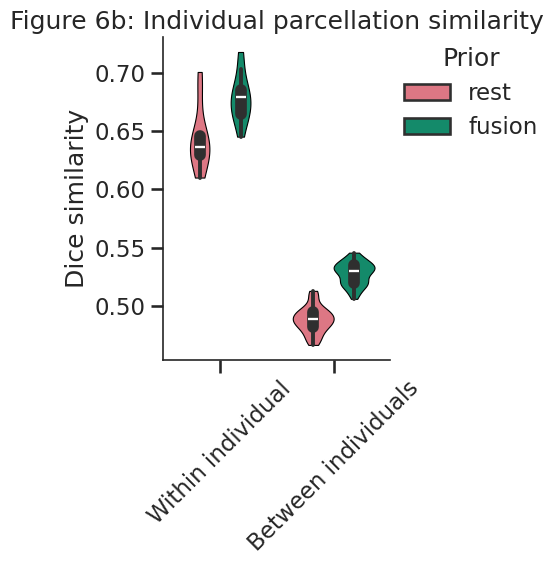

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6.6, 6))
sb.violinplot(
    data=dice_plot,
    x="w/b",
    y="dice",
    order=["within", "between"],
    hue="type",
    hue_order=HUE_ORDER,
    inner="box",
    width=0.72,
    palette=PALETTE,
    cut=0,
    ax=ax,
)

for collection in ax.collections:
    collection.set_edgecolor("black")
    collection.set_linewidth(0.8)

ax.set_title("Figure 6b: Individual parcellation similarity")
ax.set_xlabel("")
ax.set_ylabel("Dice similarity")
ax.set_xticklabels(["Within individual", "Between individuals"])
ax.tick_params(axis="x", rotation=45)
move_legend_outside(ax, anchor=(1.02, 1.0), ncol=1)
sb.despine(ax=ax)
fig.tight_layout(rect=[0, 0, 0.82, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_6b_HPN_within_between_similarity.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
def dice_group(df, prior, wb):
    return (
        df[(df["type"].astype(str) == prior) &
           (df["w/b"].astype(str) == wb)]
        .groupby("subj")["dice"]
        .mean()
    )

rest_within = dice_group(dice_plot, "rest", "within")
rest_between = dice_group(dice_plot, "rest", "between")
fusion_within = dice_group(dice_plot, "fusion", "within")
fusion_between = dice_group(dice_plot, "fusion", "between")

rows = []
for label, a, b, test in [
    ("rest: within vs between", rest_within, rest_between, "welch"),
    ("fusion: within vs between", fusion_within, fusion_between, "welch"),
    ("within: rest vs fusion", rest_within, fusion_within, "paired"),
    ("between: rest vs fusion", rest_between, fusion_between, "paired"),
]:
    if test == "paired":
        common = a.index.intersection(b.index)
        result = stats.ttest_rel(a.loc[common].sort_index(), b.loc[common].sort_index())
        n = len(common)
    else:
        result = stats.ttest_ind(a, b, equal_var=False)
        n = min(len(a), len(b))
    rows.append({
        "comparison": label,
        "test": test,
        "n": n,
        "mean_a": float(a.mean()),
        "mean_b": float(b.mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    })

dice_ttests = pd.DataFrame(rows)
numeric_cols = dice_ttests.select_dtypes(include="number").columns
dice_ttests[numeric_cols] = dice_ttests[numeric_cols].round(6)
dice_ttests

,comparison,test,n,mean_a,mean_b,t,p
0,rest: within vs between,welch,11,0.643396,0.488427,19.195197,0.0
1,fusion: within vs between,welch,11,0.677949,0.527927,24.053748,0.0
2,within: rest vs fusion,paired,11,0.643396,0.677949,-12.729027,0.0
3,between: rest vs fusion,paired,55,0.488427,0.527927,-46.728729,0.0


## Figure 6c-d: Language-Contrast Zoom-In and Z Values

Figure 6c displays the edited zoom-in PDF panel. Figure 6d plots the associated language-contrast z values for DN-B, LANG, and DN-A.

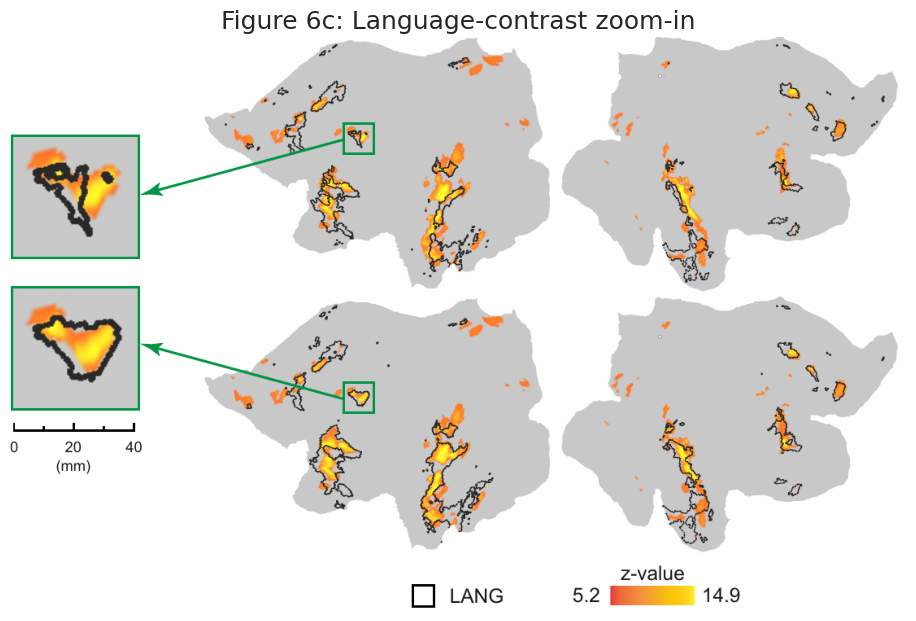

In [13]:
import subprocess
import tempfile

if not FIG6C_PDF.exists():
    raise FileNotFoundError(FIG6C_PDF)

with tempfile.TemporaryDirectory() as tmp_dir:
    png_stem = Path(tmp_dir) / "figure_6c_lang"
    subprocess.run(
        ["pdftoppm", "-png", "-singlefile", "-r", "220", str(FIG6C_PDF), str(png_stem)],
        check=True,
    )
    png_file = png_stem.with_suffix(".png")
    img = plt.imread(png_file)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 7.0))
ax.imshow(img)
ax.set_title("Figure 6c: Language-contrast zoom-in")
ax.axis("off")
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_6c_HPN_LANG_zoom_in.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
z_lang_raw = pd.read_csv(Z_VALUE_LANG_FILE, sep="\t")
FIG6D_NETWORK_ORDER = ["DN-B", "LANG", "DN-A"]

z_lang = z_lang_raw[z_lang_raw["parcel"].isin(FIG6D_NETWORK_ORDER)].copy()
z_lang["type"] = z_lang["dtype"].astype(str)
z_lang = z_lang[z_lang["type"].isin(HUE_ORDER)].copy()
z_lang["type"] = pd.Categorical(z_lang["type"], categories=HUE_ORDER, ordered=True)
z_lang["parcel"] = pd.Categorical(z_lang["parcel"], categories=FIG6D_NETWORK_ORDER, ordered=True)
z_lang = z_lang.sort_values(["parcel", "type", "subject"])

z_lang_summary = (
    z_lang
    .groupby(["parcel", "type"], observed=True)["z_value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
z_lang_summary

,parcel,type,mean,std,count
0,DN-B,rest,1.397372,1.034013,11
1,DN-B,fusion,1.280211,0.964270,11
2,LANG,rest,2.192134,0.982575,11
3,LANG,fusion,2.614360,1.028421,11
4,DN-A,rest,1.033175,0.507206,11
5,DN-A,fusion,0.881143,0.452145,11


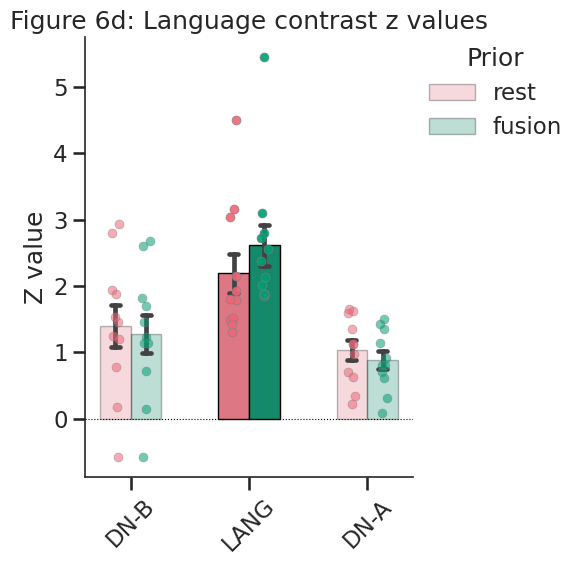

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7.4, 6))
sb.barplot(
    data=z_lang,
    x="parcel",
    y="z_value",
    hue="type",
    order=FIG6D_NETWORK_ORDER,
    hue_order=HUE_ORDER,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=PALETTE,
    dodge=True,
    ax=ax,
)

for bar in ax.patches:
    center = bar.get_x() + bar.get_width() / 2
    x_idx = int(np.round(center))
    if 0 <= x_idx < len(FIG6D_NETWORK_ORDER):
        parcel = FIG6D_NETWORK_ORDER[x_idx]
        bar.set_edgecolor(EDGE_COLOR)
        bar.set_linewidth(EDGE_WIDTH)
        if parcel != "LANG":
            bar.set_alpha(0.28)

rng = np.random.default_rng(46)
x_positions = {parcel: i for i, parcel in enumerate(FIG6D_NETWORK_ORDER)}
type_offsets = {prior: offset for prior, offset in zip(HUE_ORDER, [-BAR_WIDTH / 4, BAR_WIDTH / 4])}
for prior in HUE_ORDER:
    for parcel in FIG6D_NETWORK_ORDER:
        sub = z_lang[(z_lang["type"].astype(str) == prior) &
                     (z_lang["parcel"].astype(str) == parcel)]
        jitter = rng.uniform(-0.035, 0.035, size=len(sub))
        point_alpha = 0.9 if parcel == "LANG" else 0.55
        ax.scatter(
            x_positions[parcel] + type_offsets[prior] + jitter,
            sub["z_value"],
            s=42,
            c=PALETTE[prior],
            edgecolor="gray",
            linewidth=0.45,
            alpha=point_alpha,
            zorder=5,
        )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Figure 6d: Language contrast z values")
ax.set_xlabel("")
ax.set_ylabel("Z value")
ax.tick_params(axis="x", rotation=45)
move_legend_outside(ax, anchor=(1.02, 1.0), ncol=1)
sb.despine(ax=ax)
fig.tight_layout(rect=[0, 0, 0.82, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_6d_HPN_LANG_z_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
z_lang_rows = []
for parcel in FIG6D_NETWORK_ORDER:
    rest = z_lang[(z_lang["parcel"].astype(str) == parcel) &
                  (z_lang["type"].astype(str) == "rest")].set_index("subject")["z_value"]
    fusion = z_lang[(z_lang["parcel"].astype(str) == parcel) &
                    (z_lang["type"].astype(str) == "fusion")].set_index("subject")["z_value"]
    common = rest.index.intersection(fusion.index)
    result = stats.ttest_rel(rest.loc[common].sort_index(),
                             fusion.loc[common].sort_index())
    z_lang_rows.append({
        "parcel": parcel,
        "n": len(common),
        "mean_rest": float(rest.loc[common].mean()),
        "mean_fusion": float(fusion.loc[common].mean()),
        "mean_diff_fusion-rest": float((fusion.loc[common].sort_index() - rest.loc[common].sort_index()).mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    })

z_lang_ttests = pd.DataFrame(z_lang_rows)
numeric_cols = z_lang_ttests.select_dtypes(include="number").columns
z_lang_ttests[numeric_cols] = z_lang_ttests[numeric_cols].round(6)
z_lang_ttests

,parcel,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,DN-B,11,1.397372,1.280211,-0.117161,4.194132,0.001846
1,LANG,11,2.192134,2.614360,0.422226,-3.556537,0.005211
2,DN-A,11,1.033175,0.881143,-0.152031,4.793485,0.000731


## Figure 6e-f: Somatomotor Zoom-In and Z Values

Figure 6e displays the edited zoom-in PDF panel. Figure 6f plots the associated motor-contrast z values for SMOT-B and SMOT-A.

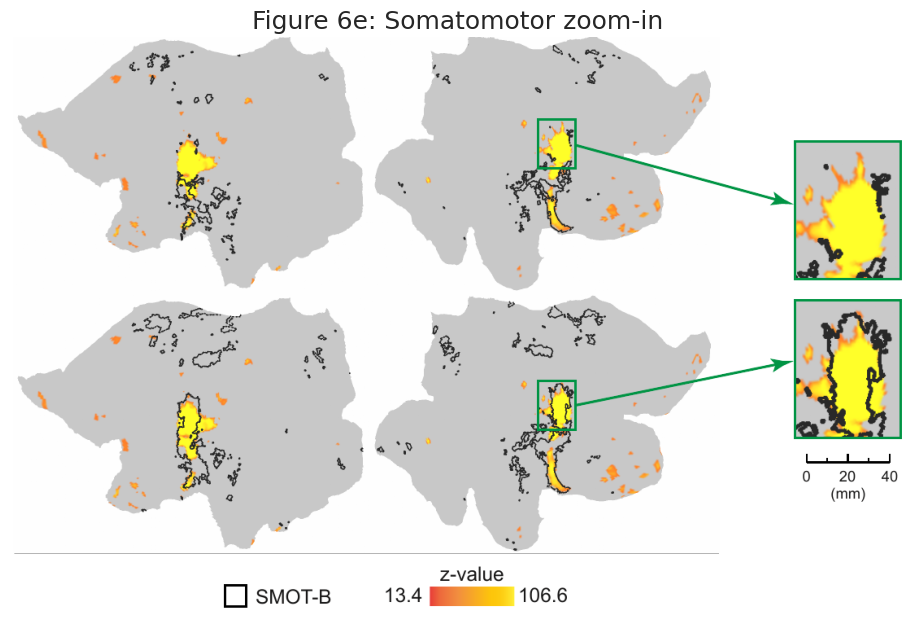

In [17]:
if not FIG6E_PDF.exists():
    raise FileNotFoundError(FIG6E_PDF)

with tempfile.TemporaryDirectory() as tmp_dir:
    png_stem = Path(tmp_dir) / "figure_6e_smb"
    subprocess.run(
        ["pdftoppm", "-png", "-singlefile", "-r", "220", str(FIG6E_PDF), str(png_stem)],
        check=True,
    )
    png_file = png_stem.with_suffix(".png")
    img = plt.imread(png_file)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 7.0))
ax.imshow(img)
ax.set_title("Figure 6e: Somatomotor zoom-in")
ax.axis("off")
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_6e_HPN_SMB_zoom_in.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
z_smb_raw = pd.read_csv(Z_VALUE_SMB_FILE, sep="\t")
FIG6F_NETWORK_ORDER = ["SMOT-B", "SMOT-A"]

z_smb = z_smb_raw[z_smb_raw["parcel"].isin(FIG6F_NETWORK_ORDER)].copy()
z_smb["type"] = z_smb["dtype"].astype(str)
z_smb = z_smb[z_smb["type"].isin(HUE_ORDER)].copy()
z_smb["type"] = pd.Categorical(z_smb["type"], categories=HUE_ORDER, ordered=True)
z_smb["parcel"] = pd.Categorical(z_smb["parcel"], categories=FIG6F_NETWORK_ORDER, ordered=True)
z_smb = z_smb.sort_values(["parcel", "type", "subject"])

z_smb_summary = (
    z_smb
    .groupby(["parcel", "type"], observed=True)["z_value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
z_smb_summary

,parcel,type,mean,std,count
0,SMOT-B,rest,20.979194,11.277513,11
1,SMOT-B,fusion,22.271898,5.153294,11
2,SMOT-A,rest,0.916251,5.324552,11
3,SMOT-A,fusion,-2.338004,3.772226,11


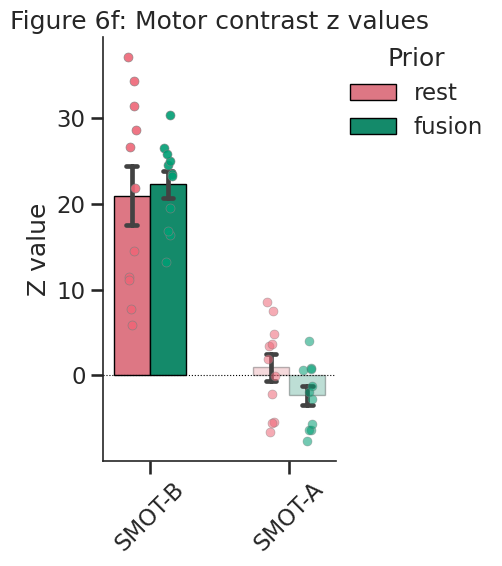

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6.4, 6))
sb.barplot(
    data=z_smb,
    x="parcel",
    y="z_value",
    hue="type",
    order=FIG6F_NETWORK_ORDER,
    hue_order=HUE_ORDER,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=PALETTE,
    dodge=True,
    ax=ax,
)

for bar in ax.patches:
    center = bar.get_x() + bar.get_width() / 2
    x_idx = int(np.round(center))
    if 0 <= x_idx < len(FIG6F_NETWORK_ORDER):
        parcel = FIG6F_NETWORK_ORDER[x_idx]
        bar.set_edgecolor(EDGE_COLOR)
        bar.set_linewidth(EDGE_WIDTH)
        if parcel != "SMOT-B":
            bar.set_alpha(0.28)

rng = np.random.default_rng(47)
x_positions = {parcel: i for i, parcel in enumerate(FIG6F_NETWORK_ORDER)}
type_offsets = {prior: offset for prior, offset in zip(HUE_ORDER, [-BAR_WIDTH / 4, BAR_WIDTH / 4])}
for prior in HUE_ORDER:
    for parcel in FIG6F_NETWORK_ORDER:
        sub = z_smb[(z_smb["type"].astype(str) == prior) &
                    (z_smb["parcel"].astype(str) == parcel)]
        jitter = rng.uniform(-0.035, 0.035, size=len(sub))
        point_alpha = 0.9 if parcel == "SMOT-B" else 0.55
        ax.scatter(
            x_positions[parcel] + type_offsets[prior] + jitter,
            sub["z_value"],
            s=42,
            c=PALETTE[prior],
            edgecolor="gray",
            linewidth=0.45,
            alpha=point_alpha,
            zorder=5,
        )

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Figure 6f: Motor contrast z values")
ax.set_xlabel("")
ax.set_ylabel("Z value")
ax.tick_params(axis="x", rotation=45)
move_legend_outside(ax, anchor=(1.02, 1.0), ncol=1)
sb.despine(ax=ax)
fig.tight_layout(rect=[0, 0, 0.82, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_6f_HPN_SMB_z_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
z_smb_rows = []
for parcel in FIG6F_NETWORK_ORDER:
    rest = z_smb[(z_smb["parcel"].astype(str) == parcel) &
                 (z_smb["type"].astype(str) == "rest")].set_index("subject")["z_value"]
    fusion = z_smb[(z_smb["parcel"].astype(str) == parcel) &
                   (z_smb["type"].astype(str) == "fusion")].set_index("subject")["z_value"]
    common = rest.index.intersection(fusion.index)
    result = stats.ttest_rel(rest.loc[common].sort_index(),
                             fusion.loc[common].sort_index())
    z_smb_rows.append({
        "parcel": parcel,
        "n": len(common),
        "mean_rest": float(rest.loc[common].mean()),
        "mean_fusion": float(fusion.loc[common].mean()),
        "mean_diff_fusion-rest": float((fusion.loc[common].sort_index() - rest.loc[common].sort_index()).mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    })

z_smb_ttests = pd.DataFrame(z_smb_rows)
numeric_cols = z_smb_ttests.select_dtypes(include="number").columns
z_smb_ttests[numeric_cols] = z_smb_ttests[numeric_cols].round(6)
z_smb_ttests

,parcel,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,SMOT-B,11,20.979194,22.271898,1.292704,-0.466172,0.651081
1,SMOT-A,11,0.916251,-2.338004,-3.254255,4.204444,0.001816
